# Briefsummary Parser

Our high throughput dft code returns text files with a summary of calculation results. Here we convert this text files to a pandas dataframe containing all the information

We use some tools developed for this propose alone. The module `Featurizer` parses the strings in the `briefsummary.dat` files and recreates information of each sample as magnetic configuration, lattice occupation signatures, etc.

# TODO: calculate formation energies and put them in the df !

In [1]:
from Tools.DatasetTools.Commoms import *
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
dataset = 'Fe-Mo' # 'Cr-Co-W',  'Fe-Mo'

# Load Brief Summary

In [2]:
BS = StructSummaryParser(dataset).BriefSummary

need to create briefsummary list
reading list of briefsummary


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [3]:
from importlib.machinery import SourceFileLoader

In [4]:
from BopFoxFeaturizer.Featurizer import Featurizer

In [38]:
Featurizer = SourceFileLoader('Featurizer','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/Featurizer.py').load_module().Featurizer

In [39]:
Features  = Featurizer(BS)

In [40]:
ground_states = Features.get_ground_states_energies()

In [41]:
ground_states

{('Fe_pv', 'FM'): -8.255294,
 ('Fe_pv', 'NM'): -8.184069,
 ('Mo_sv', 'FM'): -10.934251,
 ('Mo_sv', 'NM'): -10.934283}

In [42]:
BS['EF'] =  Features.get_formation_energies(ground_states)

<AxesSubplot:ylabel='Frequency'>

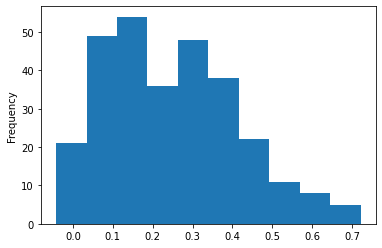

In [43]:
BS['EF'].plot.hist()

In [44]:
BS.to_pickle(f'{dataset}/ParsedBriefsummary.pkl')

In [45]:
DS

NameError: name 'DS' is not defined

In [216]:
import seaborn as sbs

In [46]:
target_mag = BS['EF'][BS['EF'].index.str.contains('FM$', regex=True)]

target_nm =  BS['EF'][BS['EF'].index.str.contains('NM$', regex=True)].to_frame()

target_nm = pd.concat([phases_nm, target_nm], axis = 1)

target_nm.index = target_nm.index.str.replace('.NM','')

target_mag.index = target_mag.index.str.replace('.FM','')

mag_nomag = pd.concat([target_nm, target_mag], axis=1)
mag_nomag.columns=['Phase','NM', 'FM']

MDIF = (mag_nomag['NM']-mag_nomag['FM']).dropna()

ax = sbs.scatterplot(x=mag_nomag['NM'], y=mag_nomag['FM'],hue=mag_nomag['Phase'])
ax.plot(mag_nomag['NM'], mag_nomag['NM'], '--k')

NameError: name 'phases_nm' is not defined